# PINN Training Notebook

This notebook trains a Physics-Informed Neural Network (PINN) for 1D heat conduction problems.

## Setup


In [ ]:
import sys
from pathlib import Path
# Load and process the selected case
import numpy as np
import scipy.io as sio
from sklearn.model_selection import train_test_split
import json
import pandas as pd
import matplotlib.pyplot as plt
# Validation: evaluate trained model on `val_batch` and show metrics/plot + architecture logging
import importlib
import math
import subprocess
import time 

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if not (ROOT / "src").exists():
    raise RuntimeError("Could not find project root containing /src")

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

print(ROOT)
import torch
from src.utils import set_seed, get_device
from src.data import load_npz_dataset, build_synthetic_batch, PINNBatch
from src.pinn import MLP, LossWeights
from src.train import train_adam, train_lbfgs
from utils.experiment_logger import append_result, compare_to_best, ensure_csv, load_best
from sklearn.model_selection import train_test_split

set_seed(42)
device = get_device()
print(f"Device: {device}") 



## Data Loading

In [ ]:
manifest = Path(ROOT, "data", "manifest.csv")

cols = [
    "case_id","L","k","rho_c","T_left","q_right_type","q_right_params",
    "Nx","t_end","alpha","dx","dt","Nt","mat_path","meta_path"
]

rows = []
with open(manifest, "r", encoding="utf-8") as f:
    header = f.readline()
    for line in f:
        parts = line.rstrip("\n").split(",")
        # first 6 are fixed, last 8 are fixed, middle belongs to q_right_params
        left = parts[:6]
        right = parts[-8:]
        q_params = ",".join(parts[6:-8])
        rows.append(left + [q_params] + right)

df = pd.DataFrame(rows, columns=cols)

# Select one case 
selected_case = df.iloc[3]  # Change index to select different case
print(f"Selected case: {selected_case['case_id']}")


Selected case: sine_A10000_T50


## Data Preprocessing

In [ ]:
case_id = selected_case["case_id"]
mat_path = Path(selected_case["mat_path"])

if not mat_path.exists():
    # Try relative path if absolute fails
    mat_path = Path(ROOT, "data", "raw", f"{case_id}.mat")
    if not mat_path.exists():
        raise FileNotFoundError(f"Data file not found: {mat_path}")

print(f"Loading: {mat_path}")

mat = sio.loadmat(mat_path)

# raw arrays
T = mat["T"]                  # (Nx, Nt)
x = mat["x"].reshape(-1)       # (Nx,)
t = mat["time"].reshape(-1)    # (Nt,)

# physical params
L = float(selected_case["L"])
alpha = float(selected_case["alpha"])
T_left = float(selected_case["T_left"])

# nondimensional coords
xi = (x / L).astype(np.float32)              # (Nx,)
tau = (alpha * t / (L**2)).astype(np.float32) # (Nt,)

# nondimensional temperature
theta = (T - T_left)
dT = float(np.max(np.abs(theta))) if np.max(np.abs(theta)) > 0 else 1.0
theta = (theta / dT).astype(np.float32)      # (Nx, Nt)

# IC (tau=0) => t index 0
theta_ic = theta[:, 0].reshape(-1, 1)
xi_ic = xi.reshape(-1, 1)
tau_ic = np.zeros_like(xi_ic, dtype=np.float32)

# Right BC (xi=1) - compute nondimensional flux
q_params = json.loads(selected_case["q_right_params"])
q_type = selected_case["q_right_type"]
k = float(selected_case["k"])
L = float(selected_case["L"])

flux_scale = k * dT / L  # for nondimensionalization

# boundary times (nondimensional) shaped (Nt, 1)
tau_bc = tau.reshape(-1, 1).astype(np.float32)

if q_type == "constant":
    q_val = float(q_params["A"])
    flux_bc = -q_val / flux_scale * np.ones_like(tau_bc, dtype=np.float32)
elif q_type == "sine":
    A = float(q_params["A"])
    omega = float(q_params["omega"])
    phase = float(q_params.get("phase", 0))
    # tau_bc is (Nt, 1), but need to compute sin(omega * tau + phase)
    flux_bc = - (A * np.sin(omega * tau_bc.flatten() + phase)) / flux_scale
    flux_bc = flux_bc.reshape(-1, 1).astype(np.float32)
elif q_type == "offset_sine":
    q0 = float(q_params["q0"])
    A = float(q_params["A"])
    omega = float(q_params["omega"])
    flux_bc = - (q0 + A * np.sin(omega * tau_bc.flatten())) / flux_scale
    flux_bc = flux_bc.reshape(-1, 1).astype(np.float32)
else:
    raise ValueError(f"Unknown q_type: {q_type}")

xi_bc = np.ones_like(tau_bc, dtype=np.float32)

# Interior data points from full grid
# theta stored (Nx, Nt) -> transpose to (Nt, Nx) for meshgrid indexing
Ttau, Xxi = np.meshgrid(tau, xi, indexing="ij")  # (Nt, Nx)
theta_grid = theta.T                              # (Nt, Nx)

xi_data_all = Xxi.reshape(-1, 1).astype(np.float32)
tau_data_all = Ttau.reshape(-1, 1).astype(np.float32)
theta_data_all = theta_grid.reshape(-1, 1).astype(np.float32)

# Split interior data into train/val 80/20
n_total = len(xi_data_all)
indices = np.arange(n_total)
train_indices, val_indices = train_test_split(indices, test_size=0.2, random_state=42)

xi_data_train = xi_data_all[train_indices]
tau_data_train = tau_data_all[train_indices]
theta_data_train = theta_data_all[train_indices]

xi_data_val = xi_data_all[val_indices]
tau_data_val = tau_data_all[val_indices]
theta_data_val = theta_data_all[val_indices]

print(f"Total data points: {n_total}")
print(f"Train data points: {len(xi_data_train)}")
print(f"Val data points: {len(xi_data_val)}")


Loading: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\data\raw\sine_A10000_T50.mat
Total data points: 51051
Train data points: 40840
Val data points: 10211


## Create Batch

In [ ]:
# Collocation points (same for train/val, or could split)
rng = np.random.default_rng(42)
n_r = 50000
xi_r = rng.uniform(0.0, 1.0, size=(n_r, 1)).astype(np.float32)
tau_r = rng.uniform(0.0, float(tau.max()), size=(n_r, 1)).astype(np.float32)

# Create train batch
train_batch = PINNBatch(
    xi_r=torch.tensor(xi_r, dtype=torch.float32, device=device),
    tau_r=torch.tensor(tau_r, dtype=torch.float32, device=device),
    xi_ic=torch.tensor(xi_ic, dtype=torch.float32, device=device),
    tau_ic=torch.tensor(tau_ic, dtype=torch.float32, device=device),
    theta_ic=torch.tensor(theta_ic, dtype=torch.float32, device=device),
    xi_bc=torch.tensor(xi_bc, dtype=torch.float32, device=device),
    tau_bc=torch.tensor(tau_bc, dtype=torch.float32, device=device),
    flux_bc=torch.tensor(flux_bc, dtype=torch.float32, device=device),
    xi_data=torch.tensor(xi_data_train, dtype=torch.float32, device=device),
    tau_data=torch.tensor(tau_data_train, dtype=torch.float32, device=device),
    theta_data=torch.tensor(theta_data_train, dtype=torch.float32, device=device),
)

# Create val batch (same IC/BC, different collocation and data)
xi_r_val = rng.uniform(0.0, 1.0, size=(n_r//5, 1)).astype(np.float32)  # Fewer for val
tau_r_val = rng.uniform(0.0, float(tau.max()), size=(n_r//5, 1)).astype(np.float32)

val_batch = PINNBatch(
    xi_r=torch.tensor(xi_r_val, dtype=torch.float32, device=device),
    tau_r=torch.tensor(tau_r_val, dtype=torch.float32, device=device),
    xi_ic=torch.tensor(xi_ic, dtype=torch.float32, device=device),
    tau_ic=torch.tensor(tau_ic, dtype=torch.float32, device=device),
    theta_ic=torch.tensor(theta_ic, dtype=torch.float32, device=device),
    xi_bc=torch.tensor(xi_bc, dtype=torch.float32, device=device),
    tau_bc=torch.tensor(tau_bc, dtype=torch.float32, device=device),
    flux_bc=torch.tensor(flux_bc, dtype=torch.float32, device=device),
    xi_data=torch.tensor(xi_data_val, dtype=torch.float32, device=device),
    tau_data=torch.tensor(tau_data_val, dtype=torch.float32, device=device),
    theta_data=torch.tensor(theta_data_val, dtype=torch.float32, device=device),
)

print("Data loaded and split successfully.")

Data loaded and split successfully.


## Training

In [ ]:
# Train the PINN model
# - validation metrics often drop early then plateau
# - tiny relative changes across checkpoints indicate convergence
# - the optimal training length depends on model/optimizer/data
model = MLP(hidden=20, layers=2).to(device)
weights = LossWeights(w_pde=1.0, w_ic=1.0, w_bc=1.0, w_data=1.0)

run_dir = Path(ROOT, "models", "checkpoints", "run")

# Train with Adam using validation-driven convergence control
best_path = train_adam(
    model,
    train_batch,
    weights,
    lr=1e-3,
    run_dir=run_dir,
    val_batch=val_batch,
    print_every=100,
    patience_evals=8,
    plateau_window=5,
    plateau_rel_tol=0.01,
    pde_guardrail_rel=0.10,
)



[Adam] step 1/20000 | total=1.9581e-01 (pde=3.84e-03, ic=3.48e-03, bc=4.36e-02, data=1.45e-01) | val_rmse=3.73e-01 | val_pde=3.13e-03 | grad=1.36e+00 | 0.1s
[Adam] step 100/20000 | total=1.2488e-01 (pde=1.18e-03, ic=4.87e-03, bc=5.07e-03, data=1.14e-01) | val_rmse=3.37e-01 | val_pde=1.18e-03 | grad=2.11e-02 | 11.8s
[Adam] step 200/20000 | total=1.2366e-01 (pde=1.59e-03, ic=5.43e-03, bc=4.74e-03, data=1.12e-01) | val_rmse=3.34e-01 | val_pde=1.60e-03 | grad=1.52e-02 | 23.2s
[Adam] step 300/20000 | total=1.2277e-01 (pde=2.12e-03, ic=5.86e-03, bc=4.38e-03, data=1.10e-01) | val_rmse=3.32e-01 | val_pde=2.13e-03 | grad=1.12e-02 | 34.4s
[Adam] step 400/20000 | total=1.2210e-01 (pde=2.62e-03, ic=6.11e-03, bc=4.03e-03, data=1.09e-01) | val_rmse=3.30e-01 | val_pde=2.63e-03 | grad=9.36e-03 | 45.9s
[Adam] step 500/20000 | total=1.2149e-01 (pde=3.00e-03, ic=6.20e-03, bc=3.72e-03, data=1.09e-01) | val_rmse=3.29e-01 | val_pde=3.01e-03 | grad=8.98e-03 | 57.2s
[Adam] step 600/20000 | total=1.2082e-01 (p

In [ ]:
# Load best model
from src.eval import load_model_weights
load_model_weights(model, best_path, device)

# Polish with LBFGS
best_lbfgs_path = train_lbfgs(
    model,
    train_batch,
    weights,
    max_iter=500,
    run_dir=run_dir,
)

print("Training completed.")


[LBFGS] starting...
[LBFGS] done | total=8.0941e-02 (pde=2.98e-03, ic=8.32e-04, bc=3.80e-03, data=7.33e-02) | grad=4.88e-03
Training completed.


## Plot

In [ ]:
# Predict temperature field on the original grid
from src.eval import predict_grid

theta_pred = predict_grid(model, tau_vals=tau, xi_vals=xi, device=device)
T_pred = T_left + dT * theta_pred

print("Predicted theta shape:", theta_pred.shape)
print("Predicted T shape:", T_pred.shape)


Predicted theta shape: (1001, 51)
Predicted T shape: (1001, 51)


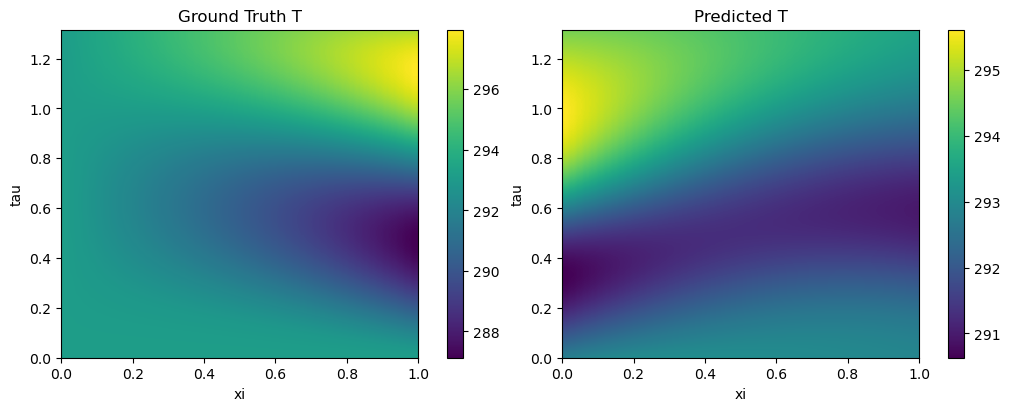

In [ ]:
# Quick comparison plot (ground truth vs prediction)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

im0 = axes[0].imshow(T.T, aspect='auto', origin='lower',
                  extent=[xi.min(), xi.max(), tau.min(), tau.max()])
axes[0].set_title('Ground Truth T')
axes[0].set_xlabel('xi')
axes[0].set_ylabel('tau')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(T_pred, aspect='auto', origin='lower',
                  extent=[xi.min(), xi.max(), tau.min(), tau.max()])
axes[1].set_title('Predicted T')
axes[1].set_xlabel('xi')
axes[1].set_ylabel('tau')
plt.colorbar(im1, ax=axes[1])

plt.show()


Loaded checkpoint: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\models\checkpoints\run\best.pt
Validation logs:
  total: 8.0680e-02
  pde: 2.9855e-03
  ic: 8.3249e-04
  bc: 3.8016e-03
  data: 7.3060e-02
  smooth: 0.0000e+00
Validation RMSE (data): 2.7030e-01


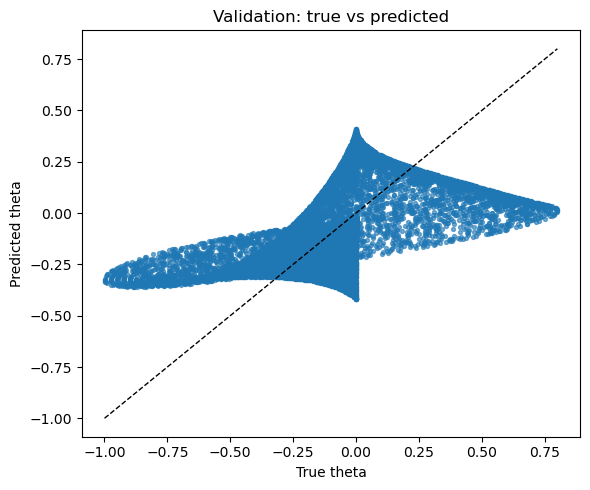

In [ ]:
# Reload train module to pick up recent edits (avoids ImportError from stale imports)
import src.train as train_mod
importlib.reload(train_mod)
from src.train import compute_losses_eval

# Load best checkpoint if available (prefer LBFGS-refined checkpoint)
ckpt = None
for name in ("best_lbfgs_path", "best_path"):
    if name in globals() and globals()[name] is not None:
        ckpt = globals()[name]
        break

if ckpt is not None and ckpt.exists():
    state = torch.load(ckpt, map_location=device)
    model.load_state_dict(state["state_dict"])
    model.to(device)
    print(f"Loaded checkpoint: {ckpt}")
else:
    print("No checkpoint found; using current in-memory model")

# Evaluate losses (keeps autograd enabled as required by PINN residuals)
val_loss, val_logs = compute_losses_eval(model, val_batch, weights)
print("Validation logs:")
for k, v in val_logs.items():
    print(f"  {k}: {v:.4e}")

# If interior validation data exists, compute predictions and show RMSE + scatter
rmse = float("nan")
if getattr(val_batch, "xi_data", None) is not None and getattr(val_batch, "theta_data", None) is not None:
    model.eval()
    with torch.no_grad():
        X_val = torch.cat([val_batch.xi_data, val_batch.tau_data], dim=1).to(device)
        y_true = val_batch.theta_data.to(device)
        y_pred = model(X_val)

    mse = torch.mean((y_pred - y_true) ** 2).item()
    rmse = mse ** 0.5
    print(f"Validation RMSE (data): {rmse:.4e}")

    plt.figure(figsize=(6, 5))
    plt.scatter(y_true.cpu().numpy(), y_pred.detach().cpu().numpy(), s=8, alpha=0.6)
    mn = min(y_true.min().item(), y_pred.min().item())
    mx = max(y_true.max().item(), y_pred.max().item())
    plt.plot([mn, mx], [mn, mx], "k--", linewidth=1)
    plt.xlabel("True theta")
    plt.ylabel("Predicted theta")
    plt.title("Validation: true vs predicted")
    plt.tight_layout()
    plt.show()
else:
    print("No interior validation data present in `val_batch` to plot.")


## Upload and update

In [ ]:
# Architecture experiment logger
results_csv = ROOT / "results" / "arch_search.csv"
ensure_csv(str(results_csv))
baseline_best = load_best(str(results_csv), metric="val_rmse_data")

def _safe_git_commit() -> str:
    try:
        out = subprocess.run(
            ["git", "rev-parse", "--short", "HEAD"],
            cwd=ROOT,
            capture_output=True,
            text=True,
            check=True,
        )
        return out.stdout.strip()
    except Exception:
        return ""

def _first_linear(module):
    for m in module.modules():
        if isinstance(m, torch.nn.Linear):
            return m
    return None

def _activation_name(module):
    for m in module.modules():
        if isinstance(m, (torch.nn.Tanh, torch.nn.ReLU, torch.nn.GELU, torch.nn.Sigmoid, torch.nn.SiLU, torch.nn.ELU, torch.nn.LeakyReLU)):
            return m.__class__.__name__.lower()
    return "unknown"

first_linear = _first_linear(model)
n_neurons = int(first_linear.out_features) if first_linear is not None else None
n_linear = sum(1 for m in model.modules() if isinstance(m, torch.nn.Linear))
n_hidden_layers = max(n_linear - 1, 0)

adam_steps = int(globals().get("N_EPOCHS", globals().get("steps", 1000)))
lbfgs_iters = int(globals().get("max_iter", 500)) if "best_lbfgs_path" in globals() else 0
optimizer_name = "adam+lbfgs" if "best_lbfgs_path" in globals() else "adam"

current_result = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "git_commit": _safe_git_commit(),
    "seed": 42,
    "n_layers": n_hidden_layers,
    "n_neurons": n_neurons,
    "activation": _activation_name(model),
    "optimizer": optimizer_name,
    "epochs": adam_steps + lbfgs_iters,
    "lr": 1e-3,
    "n_colloc": int(globals().get("n_r", 50000)),
    "n_boundary": int(getattr(train_batch, "xi_bc", torch.empty(0, 1)).shape[0]),
    "n_initial": int(getattr(train_batch, "xi_ic", torch.empty(0, 1)).shape[0]),
    "n_data": int(getattr(train_batch, "xi_data", torch.empty(0, 1)).shape[0]),
    "loss_total": float(val_logs.get("total", math.nan)),
    "loss_pde": float(val_logs.get("pde", math.nan)),
    "loss_ic": float(val_logs.get("ic", math.nan)),
    "loss_bc": float(val_logs.get("bc", math.nan)),
    "loss_data": float(val_logs.get("data", math.nan)),
    "val_rmse_data": float(rmse),
    "val_pde_loss": float(val_logs.get("pde", math.nan)),
}

improved, reason = compare_to_best(current_result, baseline_best)
append_result(str(results_csv), current_result)

def _fmt(x):
    try:
        v = float(x)
        if math.isfinite(v):
            return f"{v:.6e}"
    except Exception:
        pass
    return "nan"

print()
print("Architecture comparison:")
if baseline_best is None:
    print("Baseline best metrics: none (first recorded run)")
else:
    print(
        "Baseline best metrics: "
        f"val_rmse_data={_fmt(baseline_best.get('val_rmse_data'))}, "
        f"val_pde_loss={_fmt(baseline_best.get('val_pde_loss'))}, "
        f"loss_total={_fmt(baseline_best.get('loss_total'))}"
    )

print(
    "Current metrics: "
    f"val_rmse_data={_fmt(current_result.get('val_rmse_data'))}, "
    f"val_pde_loss={_fmt(current_result.get('val_pde_loss'))}, "
    f"loss_total={_fmt(current_result.get('loss_total'))}"
)
print(("? IMPROVED: " if improved else "? NOT IMPROVED: ") + reason)
print(f"Logged run to {results_csv}")




Architecture comparison:
Baseline best metrics: val_rmse_data=4.817587e-03, val_pde_loss=3.772722e-04, loss_total=2.666410e-03
Current metrics: val_rmse_data=2.702966e-01, val_pde_loss=2.985534e-03, loss_total=8.067990e-02
? NOT IMPROVED: RMSE gain -2.654790e-01 is below threshold 1.000000e-04.
Logged run to c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\results\arch_search.csv
